In [24]:
# przetwarzanie danych
import numpy as np
import pandas as pd

# przekształcanie – normalizacja danych
from sklearn.preprocessing import MinMaxScaler

# wizualizacja
import matplotlib.pyplot as plt

# sieci neuronowe
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import SimpleRNN
from keras.layers import LSTM
from keras.layers import GRU

# ewaluacja modelu
from sklearn.metrics import mean_squared_error

In [25]:
dataset = pd.read_csv('airline-passengers.csv')
dataset['Month'] = pd.to_datetime(dataset['Month'])
dataset.set_index(['Month'], inplace=True)
dataset

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


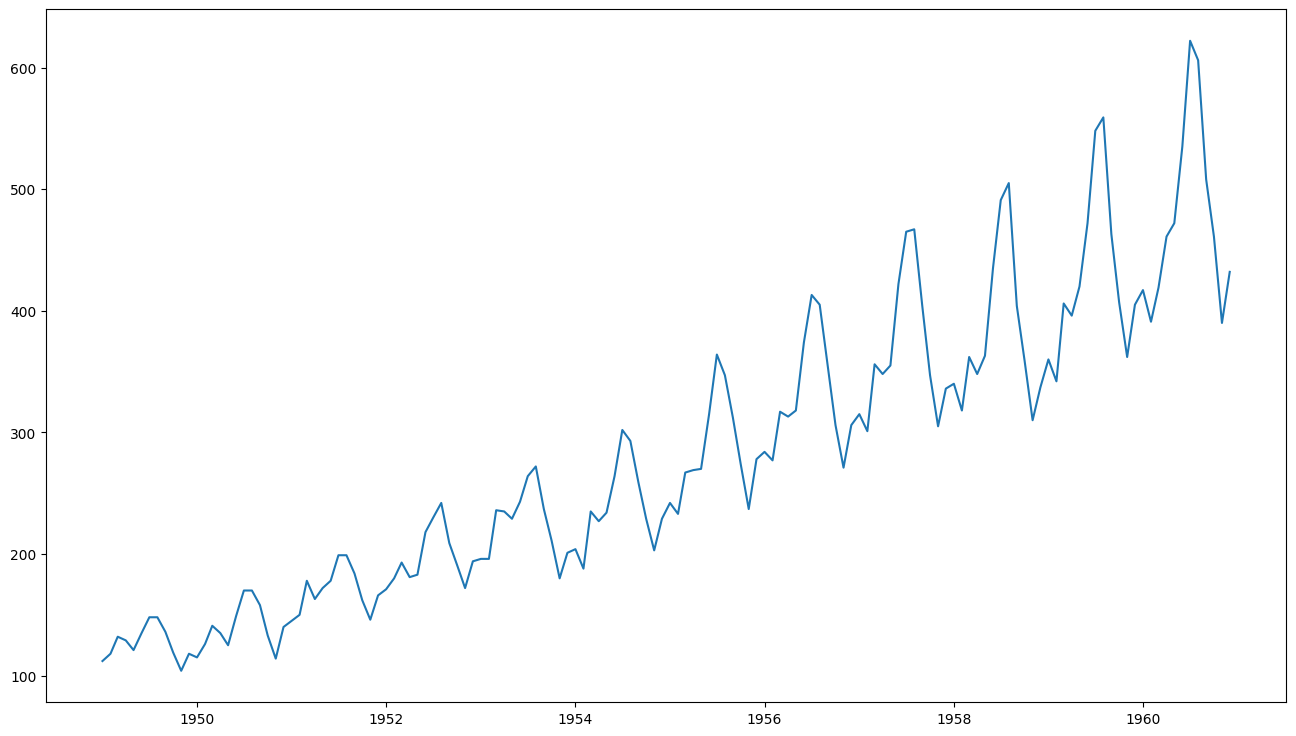

In [26]:
plt.figure(figsize=(16,9))
plt.plot(dataset['Passengers'])
plt.show()

In [27]:
train_size = int(len(dataset) * 0.70)
scaler = MinMaxScaler(feature_range=(0, 1))
look_back = 3
def create_dataset(df, train_size, lback=look_back, scaler_function=scaler):
    test_size = len(df) - train_size
    train, test = df[0:train_size,:].copy(), df[train_size - lback:len(df),:].copy()
    train = scaler_function.fit_transform(train)
    test = scaler_function.transform(test)
    X_train, X_test, y_train, y_test = [], [], [], []

    # Tworzenie zbioru treninowego
    for i in range(len(train)-lback):
        a = train[i:(i+lback), 0]
        X_train.append(a)
        y_train.append(train[i + lback, 0])

    # Tworzenie zbioru testowego
    for i in range(test_size):
        a = test[i:(i+lback), 0]
        X_test.append(a)
        y_test.append(test[i + lback, 0])

    X_train, X_test = np.array(X_train), np.array(X_test)
    X_train, X_test = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1])), np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
    y_train, y_test = np.array(y_train), np.array(y_test)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = create_dataset(df=np.array(dataset), train_size=train_size, lback=look_back)

X_train[:3]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

validation_size = int(len(X_train) * 0.20)

X_val = X_train[-validation_size:]
y_val = y_train[-validation_size:]

X_train = X_train[:-validation_size]
y_train = y_train[:-validation_size]

(97, 1, 3)
(44, 1, 3)
(97,)
(44,)


In [28]:
def fn_model_rnn(units):
    model_rnn = Sequential()
    model_rnn.add(SimpleRNN(units=units, input_shape=(1, look_back)))
    model_rnn.add(Dense(1))
    model_rnn.compile(loss='mean_squared_error', optimizer='adam')
    model_rnn.fit(X_train, y_train, epochs=200, batch_size=1, verbose=0)
    return model_rnn

In [29]:
def backtests(model, lback=look_back):

    # predykcja - train
    prediction_train = scaler.inverse_transform(model.predict(X_train))
    prediction_train = pd.Series(prediction_train.flatten(),
                                index=dataset.index[lback:lback + len(prediction_train)])

    # predykcja - validation
    prediction_val = scaler.inverse_transform(model.predict(X_val))
    prediction_val = pd.Series(prediction_val.flatten(),
                                    index=dataset.index[lback + len(prediction_train):lback + len(prediction_train) + len(prediction_val)])

    # predykcja - test
    prediction_test = scaler.inverse_transform(model.predict(X_test))
    prediction_test = pd.Series(prediction_test.flatten(),
                                index=dataset.index[train_size:])

    # wizualizacja prognozy
    plt.figure(figsize=(16,9))
    plt.plot(dataset['Passengers'], color='blue', label='True values')
    plt.plot(prediction_train, color='green', label='Prediction - Train')
    plt.plot(prediction_val, color='yellow', label='Prediction - Val')
    plt.plot(prediction_test, color='red', label='Prediction - Test')
    plt.legend(loc='upper left')
    plt.show()

    # obliczenie RMSE
    rmse = mean_squared_error(dataset.loc[prediction_test.index, :], prediction_test) ** 0.5
    print(f'\nRMSE TEST: {rmse}')

# backtests(model_rnn)

In [35]:
def calculate_error(model, lback=look_back):
    # predykcja - train
    prediction_train = scaler.inverse_transform(model.predict(X_train,verbose=0))
    prediction_train = pd.Series(prediction_train.flatten(),
                                index=dataset.index[lback:lback + len(prediction_train)])

    # predykcja - validation
    prediction_val = scaler.inverse_transform(model.predict(X_val,verbose=0))
    prediction_val = pd.Series(prediction_val.flatten(),
                                    index=dataset.index[lback + len(prediction_train):lback + len(prediction_train) + len(prediction_val)])

    rmse = mean_squared_error(dataset.loc[prediction_val.index, :], prediction_val) ** 0.5
    return rmse


In [31]:
def fn_model_lstm(units):
    model_lstm = Sequential()
    model_lstm.add(LSTM(units=units, input_shape=(1, look_back)))
    model_lstm.add(Dense(1))
    model_lstm.compile(loss='mean_squared_error', optimizer='adam')
    model_lstm.fit(X_train, y_train, epochs=200, batch_size=1, verbose=0)
    return model_lstm

In [32]:
def fn_model_gru(units):
    model_gru = Sequential()
    model_gru.add(GRU(units=units, input_shape=(1, look_back)))
    model_gru.add(Dense(1))
    model_gru.compile(loss='mean_squared_error', optimizer='adam')
    model_gru.fit(X_train, y_train, epochs=200, batch_size=1, verbose=0)
    return model_gru

In [36]:
results = []
best_model_type = None
best_look_back = None
best_units = None
best_rmse = np.inf

for look_back in range(1,13):
    X_train, X_test, y_train, y_test = create_dataset(df=np.array(dataset), train_size=train_size, lback=look_back, scaler_function=scaler)
    validation_size = int(len(X_train) * 0.20)
    X_val = X_train[-validation_size:]
    y_val = y_train[-validation_size:]
    X_train = X_train[:-validation_size]
    y_train = y_train[:-validation_size]
    for units in range(1,13):
        models = {
            "GRU": fn_model_gru,
            "LSTM": fn_model_lstm,
            "RNN": fn_model_rnn
        }
        for model_type , model_function in models.items():
            model = model_function(units)
            
            rmse_val = calculate_error(model, lback=look_back)
            results.append({
                "model": model_type,
                "look_back": look_back,
                "units": units,
                "RMSE_validation": rmse_val
            })
            print(
            f"{model_type} | "
            f"look_back={look_back} | "
            f"units={units} | "
            f"RMSE={rmse_val:.3f}"
            )
            if rmse_val < best_rmse:
                best_rmse = rmse_val
                best_model_type = model_type
                best_look_back = look_back
                best_units = units
    

GRU | look_back=1 | units=1 | RMSE=34.796
LSTM | look_back=1 | units=1 | RMSE=34.470
RNN | look_back=1 | units=1 | RMSE=35.976
GRU | look_back=1 | units=2 | RMSE=34.394
LSTM | look_back=1 | units=2 | RMSE=34.445
RNN | look_back=1 | units=2 | RMSE=35.908
GRU | look_back=1 | units=3 | RMSE=35.257
LSTM | look_back=1 | units=3 | RMSE=33.832
RNN | look_back=1 | units=3 | RMSE=35.043
GRU | look_back=1 | units=4 | RMSE=33.023
LSTM | look_back=1 | units=4 | RMSE=33.603
RNN | look_back=1 | units=4 | RMSE=34.038
GRU | look_back=1 | units=5 | RMSE=34.041
LSTM | look_back=1 | units=5 | RMSE=33.488
RNN | look_back=1 | units=5 | RMSE=34.908
GRU | look_back=1 | units=6 | RMSE=32.978
LSTM | look_back=1 | units=6 | RMSE=32.659
RNN | look_back=1 | units=6 | RMSE=34.470
GRU | look_back=1 | units=7 | RMSE=33.123
LSTM | look_back=1 | units=7 | RMSE=33.297
RNN | look_back=1 | units=7 | RMSE=32.624
GRU | look_back=1 | units=8 | RMSE=33.396
LSTM | look_back=1 | units=8 | RMSE=33.586
RNN | look_back=1 | units=

2/2 [==============================] - 0s 2ms/step


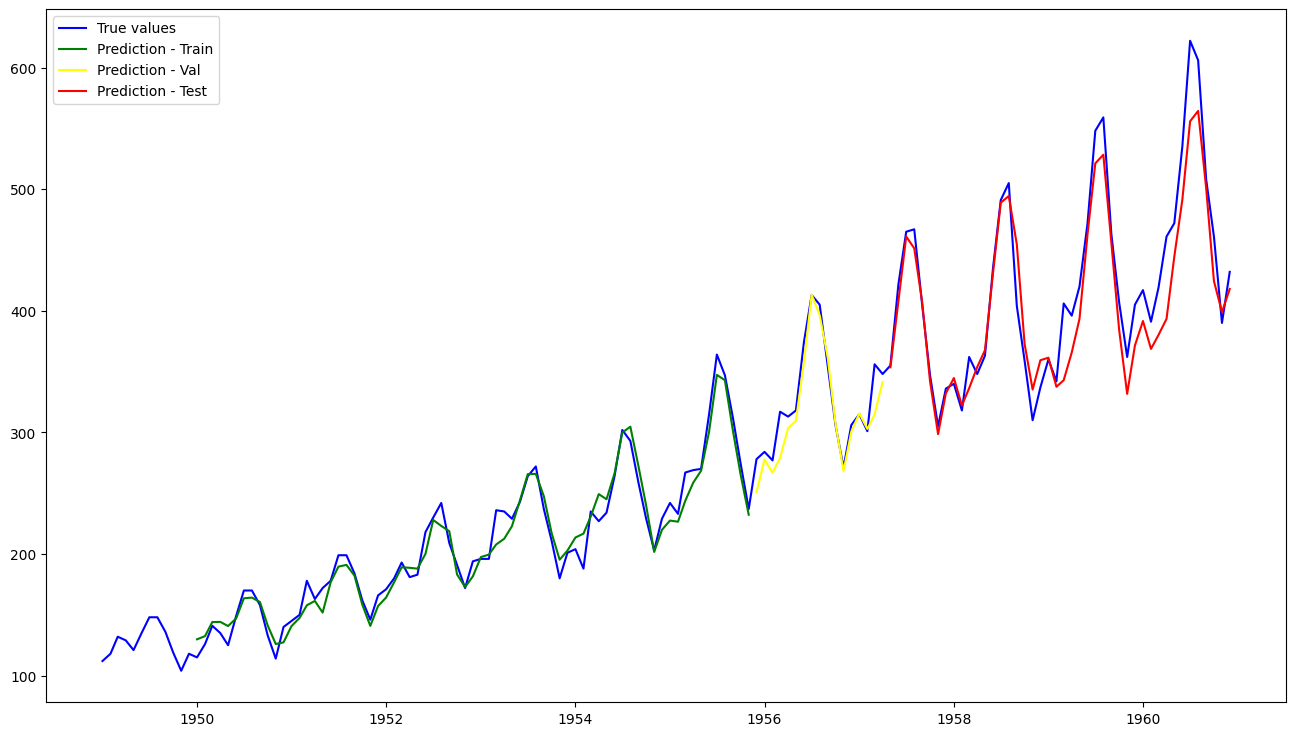


RMSE TEST: 27.375706772411604
best model type = Sequential
best look back = 12
best units = 4


In [42]:

look_back = best_look_back

X_train, X_test, y_train, y_test = create_dataset(df=np.array(dataset), train_size=train_size, lback=look_back, scaler_function=scaler)
validation_size = int(len(X_train) * 0.20)
X_val = X_train[-validation_size:]
y_val = y_train[-validation_size:]
X_train = X_train[:-validation_size]
y_train = y_train[:-validation_size]
best_model = models[best_model_type](best_units)

backtests(best_model,best_look_back)
print(
    f"best model type = {type(best_model).__name__}\n"
    f"best look back = {best_look_back}\n"
    f"best units = {best_units}"
)